In [127]:
import tqdm
import numpy as np
import matplotlib.pyplot as plt

import torch
import gpytorch


First, let's generate some data.

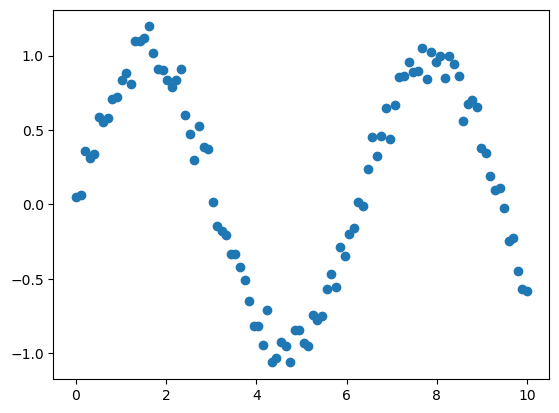

In [105]:
X = np.linspace(0, 10, 100)
y = np.sin(X) + np.random.normal(0, 0.1, X.shape)

plt.plot(X, y, 'o')
plt.show()

# Let's create a simple Gaussian process to fit this data

In [106]:
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [107]:
# Fit the Gaussian process model to the data
X = torch.from_numpy(X).float()
y = torch.from_numpy(y).float()

likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ExactGPModel(X, y, likelihood)

model.train()
likelihood.train()

optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

training_iter = 50

for i in range(training_iter):
    optimizer.zero_grad()
    output = model(X)
    loss = -mll(output, y)
    loss.backward()
    print('Iter %d/%d - Loss: %.3f' % (i + 1, training_iter, loss.item()))
    optimizer.step()

Iter 1/50 - Loss: 0.892
Iter 2/50 - Loss: 0.852
Iter 3/50 - Loss: 0.812
Iter 4/50 - Loss: 0.773
Iter 5/50 - Loss: 0.733
Iter 6/50 - Loss: 0.693
Iter 7/50 - Loss: 0.653
Iter 8/50 - Loss: 0.613
Iter 9/50 - Loss: 0.574
Iter 10/50 - Loss: 0.535
Iter 11/50 - Loss: 0.496
Iter 12/50 - Loss: 0.457
Iter 13/50 - Loss: 0.418
Iter 14/50 - Loss: 0.379
Iter 15/50 - Loss: 0.339
Iter 16/50 - Loss: 0.298
Iter 17/50 - Loss: 0.257
Iter 18/50 - Loss: 0.215
Iter 19/50 - Loss: 0.172
Iter 20/50 - Loss: 0.130
Iter 21/50 - Loss: 0.087
Iter 22/50 - Loss: 0.044
Iter 23/50 - Loss: 0.002
Iter 24/50 - Loss: -0.039
Iter 25/50 - Loss: -0.081
Iter 26/50 - Loss: -0.122
Iter 27/50 - Loss: -0.162
Iter 28/50 - Loss: -0.202
Iter 29/50 - Loss: -0.242
Iter 30/50 - Loss: -0.281
Iter 31/50 - Loss: -0.319
Iter 32/50 - Loss: -0.356
Iter 33/50 - Loss: -0.393
Iter 34/50 - Loss: -0.428
Iter 35/50 - Loss: -0.462
Iter 36/50 - Loss: -0.494
Iter 37/50 - Loss: -0.525
Iter 38/50 - Loss: -0.554
Iter 39/50 - Loss: -0.581
Iter 40/50 - Loss:

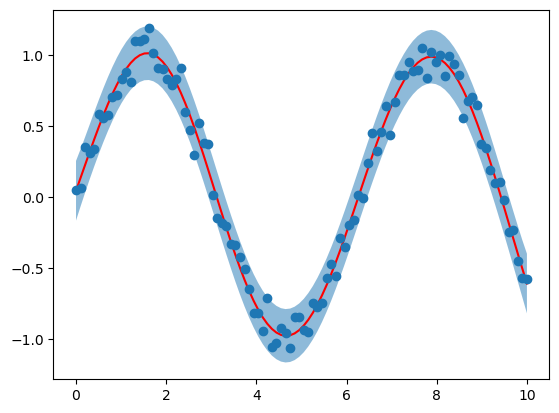

In [108]:
# Produce the predictive distribution
model.eval()
likelihood.eval()

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    observed_pred = likelihood(model(X))
    lower, upper = observed_pred.confidence_region()


plt.plot(X.numpy(), observed_pred.mean.numpy(), 'r')
plt.fill_between(X.numpy(), lower.numpy(), upper.numpy(), alpha=0.5)
plt.plot(X.numpy(), y.numpy(), 'o')
plt.show()

# Now, let's also show an example with a sparse dataset
This highlights another reason I like GPs.

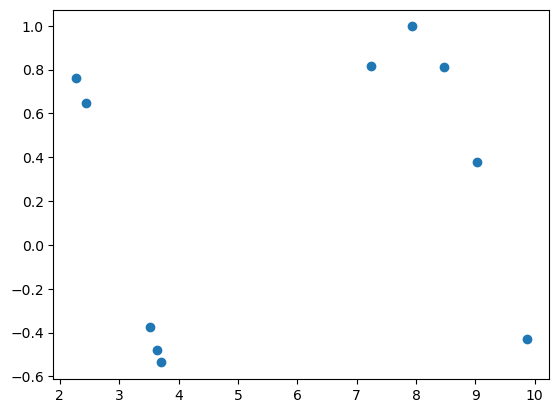

In [109]:
X = np.random.rand(10, 1) * 10
X = np.sort(X.flatten())#.flatten()
y = np.sin(X) #+ np.random.normal(0, 0.1, X.shape)
plt.plot(X, y, 'o')

In [110]:
# Fit the Gaussian process model to the data
X = torch.from_numpy(X).float()
y = torch.from_numpy(y).float()

likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ExactGPModel(X, y, likelihood)

model.train()
likelihood.train()

optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

training_iter = 50

for i in range(training_iter):
    optimizer.zero_grad()
    output = model(X)
    loss = -mll(output, y)
    loss.backward()
    print('Iter %d/%d - Loss: %.3f' % (i + 1, training_iter, loss.item()))
    optimizer.step()

Iter 1/50 - Loss: 1.119
Iter 2/50 - Loss: 1.077
Iter 3/50 - Loss: 1.041
Iter 4/50 - Loss: 1.009
Iter 5/50 - Loss: 0.982
Iter 6/50 - Loss: 0.956
Iter 7/50 - Loss: 0.929
Iter 8/50 - Loss: 0.902
Iter 9/50 - Loss: 0.874
Iter 10/50 - Loss: 0.847
Iter 11/50 - Loss: 0.821
Iter 12/50 - Loss: 0.797
Iter 13/50 - Loss: 0.775
Iter 14/50 - Loss: 0.753
Iter 15/50 - Loss: 0.731
Iter 16/50 - Loss: 0.708
Iter 17/50 - Loss: 0.686
Iter 18/50 - Loss: 0.666
Iter 19/50 - Loss: 0.649
Iter 20/50 - Loss: 0.634
Iter 21/50 - Loss: 0.618
Iter 22/50 - Loss: 0.601
Iter 23/50 - Loss: 0.583
Iter 24/50 - Loss: 0.565
Iter 25/50 - Loss: 0.546
Iter 26/50 - Loss: 0.526
Iter 27/50 - Loss: 0.505
Iter 28/50 - Loss: 0.483
Iter 29/50 - Loss: 0.462
Iter 30/50 - Loss: 0.441
Iter 31/50 - Loss: 0.420
Iter 32/50 - Loss: 0.400
Iter 33/50 - Loss: 0.379
Iter 34/50 - Loss: 0.359
Iter 35/50 - Loss: 0.338
Iter 36/50 - Loss: 0.318
Iter 37/50 - Loss: 0.298
Iter 38/50 - Loss: 0.279
Iter 39/50 - Loss: 0.259
Iter 40/50 - Loss: 0.240
Iter 41/5

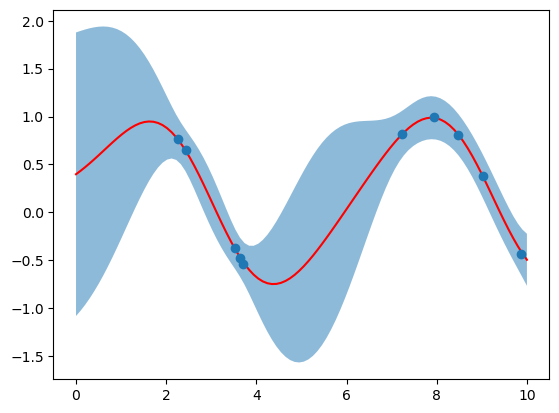

In [111]:
# Produce the predictive distribution
model.eval()
likelihood.eval()

test_X = torch.tensor(np.linspace(0, 10, 100)).float()
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    observed_pred = likelihood(model(test_X))
    lower, upper = observed_pred.confidence_region()


plt.plot(test_X.numpy(), observed_pred.mean.numpy(), 'r')
plt.fill_between(test_X.numpy(), lower.numpy(), upper.numpy(), alpha=0.5)
plt.plot(X.numpy(), y.numpy(), 'o')
plt.show()

So, we see that our model is producing tighter estimates where we have data, and wider estimates where we do not!

Let's demonstrate how to do this with an ApproximateGP -- where we are learning the inducing points.

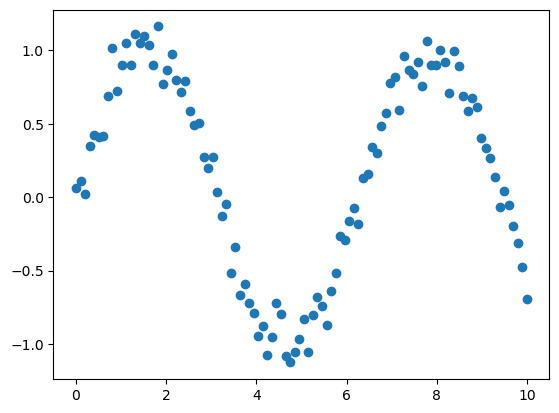

In [210]:
X = np.linspace(0, 10, 100)
y = np.sin(X) + np.random.normal(0, 0.1, X.shape)

plt.plot(X, y, 'o')
plt.show()

In [211]:
X = torch.from_numpy(X).float()
y = torch.from_numpy(y).float()

dataset = torch.utils.data.TensorDataset(X, y)
train_loader = torch.utils.data.DataLoader(dataset, batch_size=10, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset, batch_size=10, shuffle=False)

In [275]:
from gpytorch.models import ApproximateGP
from gpytorch.variational import CholeskyVariationalDistribution
from gpytorch.variational import VariationalStrategy

class GPModel(ApproximateGP):
    def __init__(self, inducing_points):
        variational_distribution = CholeskyVariationalDistribution(inducing_points.size(0))
        variational_strategy = VariationalStrategy(self, inducing_points, variational_distribution, learn_inducing_locations=True)
        super(GPModel, self).__init__(variational_strategy)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

num_inducing_points = 10
inducing_points = torch.linspace(0, 10, num_inducing_points)
model = GPModel(inducing_points=inducing_points)
likelihood = gpytorch.likelihoods.GaussianLikelihood()

In [276]:
num_epochs = 10

model.train()
likelihood.train()

optimizer = torch.optim.Adam([
    {'params': model.parameters()},
    {'params': likelihood.parameters()},
], lr=0.01)

# Our loss object. We're using the VariationalELBO
mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=y.size(0))
epochs_iter = tqdm.notebook.tqdm(range(num_epochs), desc="Epoch")


for i in epochs_iter:
    # Within each iteration, we will go over each minibatch of data
    minibatch_iter = tqdm.notebook.tqdm(train_loader, desc="Minibatch", leave=False)
    for x_batch, y_batch in minibatch_iter:
        optimizer.zero_grad()
        output = model(x_batch)
        loss = -mll(output, y_batch)
        minibatch_iter.set_postfix(loss=loss.item())
        loss.backward()
        optimizer.step()

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/10 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/10 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/10 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/10 [00:00<?, ?it/s]

...

Minibatch:   0%|          | 0/10 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/10 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/10 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/10 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/10 [00:00<?, ?it/s]

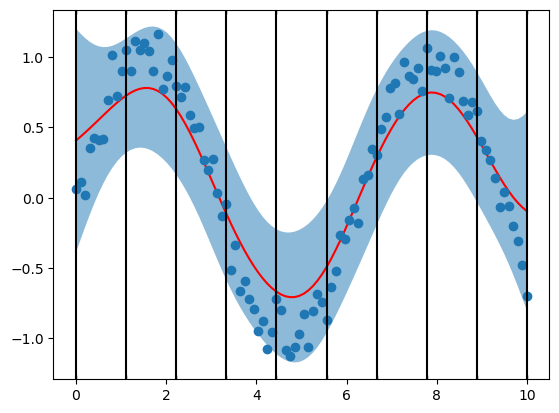

In [277]:
model.eval()
likelihood.eval()
means = torch.tensor([0.])
lowers, uppers = torch.tensor([0.]), torch.tensor([0.])
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        preds = model(x_batch)
        means = torch.cat([means, preds.mean.cpu()])
        lower, upper = preds.confidence_region()
        lowers = torch.cat([lowers, lower.cpu()])
        uppers = torch.cat([uppers, upper.cpu()])
means = means[1:]
lowers = lowers[1:]
uppers = uppers[1:]

# Create plot
plt.plot(X.numpy(), means.numpy(), 'r')
plt.fill_between(X.numpy(), lowers.numpy(), uppers.numpy(), alpha=0.5)
plt.plot(X.numpy(), y.numpy(), 'o')

# Plot vertical lines at the inducing point locations
for i in range(inducing_points.size(0)):
    plt.axvline(inducing_points[i].item(), color='k', marker='|')
plt.show()

So, we have a way to train a GP on a much larger dataset, using a smaller number of inducing points.